<a href="https://colab.research.google.com/github/Savara-k/Information-Retrieval-System-Using-TF-IDF-and-BM25/blob/main/IRFINAL_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Information Retrieval System Using TF-IDF and BM25

This project implements a full classical Information Retrieval system including:
- Text preprocessing and indexing
- Boolean query handling
- TF-IDF and BM25 ranking models
- Ranked retrieval and evaluation using standard IR metrics

The goal is to compare ranking effectiveness across models using a standard document collection.


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess(text):
    """
    Full preprocessing pipeline:
    - lowercasing
    - tokenizing
    - removing stopwords
    - stemming
    """
    text = text.lower()
    tokens = re.findall(r"[a-zA-Z0-9]+", text)

    processed = []
    for token in tokens:
        if token not in stop_words:
            processed.append(stemmer.stem(token))
    return processed


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from collections import defaultdict
import math
import os

class InvertedIndex:
    def __init__(self):
        self.index = defaultdict(list)
        self.doc_lengths = {}
        self.N = 0
        self.avgdl = 0

    def add_document(self, doc_id, text):
        tokens = preprocess(text)
        tf = defaultdict(int)

        for t in tokens:
            tf[t] += 1

        length = sum(tf.values())
        self.doc_lengths[doc_id] = length
        self.N += 1

        for term, freq in tf.items():
            self.index[term].append((doc_id, freq))

    def finalize(self):
        total_len = sum(self.doc_lengths.values())
        self.avgdl = total_len / self.N if self.N else 0

    def idf(self, term):
        df = len(self.index.get(term, []))
        if df == 0:
            return 0
        return math.log((self.N - df + 0.5) / (df + 0.5) + 1)


In [ ]:
import math

class Ranker:
    def __init__(self, index):
        self.index = index

    def tfidf_score(self, query):
        query_terms = preprocess(query)
        doc_scores = defaultdict(float)

        for term in query_terms:
            postings = self.index.index.get(term, [])
            idf = self.index.idf(term)
            for (doc, tf) in postings:
                doc_scores[doc] += (tf * idf)

        for doc in doc_scores:
            doc_scores[doc] /= self.index.doc_lengths[doc]

        return sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)

    def bm25(self, query, k1=1.5, b=0.75):
        query_terms = preprocess(query)
        doc_scores = defaultdict(float)

        for term in query_terms:
            postings = self.index.index.get(term, [])
            idf = self.index.idf(term)
            for (doc, tf) in postings:
                dl = self.index.doc_lengths[doc]
                denom = tf + k1 * (1 - b + b * (dl / self.index.avgdl))
                score = idf * (tf * (k1 + 1)) / denom
                doc_scores[doc] += score

        return sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)


In [ ]:
def boolean_retrieval(query, index):
    """
    Example:
    "apple AND banana"
    "pain OR fever"
    """
    tokens = query.split()

    if "AND" in tokens:
        a, b = query.split("AND")
        a_terms = preprocess(a)
        b_terms = preprocess(b)

        a_docs = get_docs(a_terms, index)
        b_docs = get_docs(b_terms, index)

        return sorted(a_docs & b_docs)

    elif "OR" in tokens:
        a, b = query.split("OR")
        a_terms = preprocess(a)
        b_terms = preprocess(b)

        a_docs = get_docs(a_terms, index)
        b_docs = get_docs(b_terms, index)

        return sorted(a_docs | b_docs)

def get_docs(terms, index):
    docs = set()
    for t in terms:
        postings = index.index.get(t, [])
        for (doc, tf) in postings:
            docs.add(doc)
    return docs


In [ ]:
def precision_at_k(ranked_docs, relevant, k):
    retrieved = ranked_docs[:k]
    hits = sum(1 for d in retrieved if d in relevant)
    return hits / k

def recall_at_k(ranked_docs, relevant, k):
    retrieved = ranked_docs[:k]
    hits = sum(1 for d in retrieved if d in relevant)
    return hits / len(relevant)

def mean_average_precision(ranked_docs, relevant):
    score = 0
    hits = 0
    for i, doc in enumerate(ranked_docs):
        if doc in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / len(relevant)

def mrr(ranked_docs, relevant):
    for i, doc in enumerate(ranked_docs):
        if doc in relevant:
            return 1 / (i + 1)
    return 0


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

def visualize_tfidf(doc_vectors):
    docs = list(doc_vectors.keys())
    matrix = np.array(list(doc_vectors.values()))

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(matrix)

    plt.figure(figsize=(8,6))
    plt.scatter(reduced[:,0], reduced[:,1], c="blue")

    for i, d in enumerate(docs):
        plt.annotate(d, (reduced[i,0], reduced[i,1]))

    plt.title("TF-IDF Document Space (PCA Reduced)")
    plt.show()


In [ ]:
!mkdir -p sample_docs

docs = {
    1: "The quick brown fox jumps over the lazy dog. Government funding is important for transportation.",
    2: "Lazy dog is sleeping. The cat watches the mouse. More funding for public transportation is needed.",
    3: "Brown fox and lazy dog are friends. The government should provide funds for infrastructure and transportation projects.",
    4: "The cat is quick and agile. Funding for art and culture is also important.",
    5: "Government funding supports transportation systems and public infrastructure.",
    6: "Transportation funding helps repair roads, bridges, and railways.",
    7: "Public transportation reduces traffic congestion and pollution.",
    8: "The government announced new funding for highway transportation.",
    9: "Infrastructure projects depend heavily on government funding.",
    10: "Transportation systems include buses, trains, and subways.",
    11: "The fox ran across the highway near the transportation hub.",
    12: "Funding cuts can negatively impact transportation services.",
    13: "Public funding is critical for urban transportation development.",
    14: "Government investment improves transportation safety and efficiency.",
    15: "Transportation funding also supports rural communities.",
    16: "The lazy dog slept near the train station.",
    17: "Infrastructure funding creates jobs in transportation sectors.",
    18: "Government transportation grants fund bridge repairs.",
    19: "Transportation policy affects economic growth.",
    20: "Public transit funding supports low-income communities.",
    21: "The fox and dog crossed the road near a construction site.",
    22: "Transportation infrastructure includes airports and ports.",
    23: "Government funding helps modernize transportation technology.",
    24: "Transportation projects require long-term financial planning.",
    25: "Public transportation funding improves city mobility.",
    26: "The government increased funding for green transportation.",
    27: "Transportation networks connect cities and regions.",
    28: "Federal funding supports state transportation programs.",
    29: "Infrastructure development boosts transportation efficiency.",
    30: "Transportation funding decisions impact daily commuters.",
    31: "The cat observed traffic near the transportation center.",
    32: "Government transportation budgets prioritize safety upgrades.",
    33: "Public funding enables large-scale transportation projects.",
    34: "Transportation systems rely on consistent funding streams.",
    35: "Infrastructure investment strengthens transportation resilience.",
    36: "The dog waited near the bus stop.",
    37: "Transportation funding supports maintenance and expansion.",
    38: "Government agencies oversee transportation funding allocation.",
    39: "Transportation infrastructure is essential for trade.",
    40: "Public transportation funding reduces carbon emissions.",
    41: "The fox ran along the railway tracks.",
    42: "Transportation funding supports innovation and research.",
    43: "Government funding improves transportation accessibility.",
    44: "Infrastructure and transportation are closely linked.",
    45: "Transportation funding ensures system reliability.",
    46: "The dog slept beside the highway.",
    47: "Public transportation funding benefits urban planning.",
    48: "Transportation investments enhance national infrastructure.",
    49: "Government funding is vital for sustainable transportation.",
    50: "Transportation projects rely on federal and state funding."
}

for i, text in docs.items():
    with open(f"sample_docs/doc{i}.txt", "w") as f:
        f.write(text)

print("Created 50 sample documents in 'sample_docs/'")


Created 50 sample documents in 'sample_docs/'


In [ ]:
import os

index = InvertedIndex()

for fname in os.listdir("sample_docs"):
    text = open(f"sample_docs/{fname}").read()
    index.add_document(fname, text)

index.finalize()

ranker = Ranker(index)

query = "government funding transportation"

print("\nTF-IDF Ranking:")
tfidf = ranker.tfidf_score(query)
print(tfidf)

print("\nBM25 Ranking:")
bm = ranker.bm25(query)
print(bm)

print("\nBoolean Retrieval Example:")
print(boolean_retrieval("government AND funding", index))

relevant = ["doc1.txt", "doc3.txt"]

ranked_list = [d for (d,score) in bm]

print("\nPrecision@5:", precision_at_k(ranked_list, relevant, 5))
print("\nRecall@5:", recall_at_k(ranked_list, relevant, 5))
print("\nMAP:", mean_average_precision(ranked_list, relevant))
print("\nMRR:", mrr(ranked_list, relevant))



TF-IDF Ranking:
[('doc26.txt', 0.40511129063697127), ('doc43.txt', 0.40511129063697127), ('doc49.txt', 0.40511129063697127), ('doc38.txt', 0.33759274219747604), ('doc8.txt', 0.33759274219747604), ('doc18.txt', 0.33759274219747604), ('doc23.txt', 0.33759274219747604), ('doc9.txt', 0.3072058160651503), ('doc5.txt', 0.2893652075978366), ('doc14.txt', 0.2519095840123161), ('doc32.txt', 0.2519095840123161), ('doc1.txt', 0.20255564531848563), ('doc3.txt', 0.18414149574407784), ('doc42.txt', 0.1392841011809829), ('doc45.txt', 0.1392841011809829), ('doc37.txt', 0.1392841011809829), ('doc34.txt', 0.11607008431748574), ('doc25.txt', 0.11607008431748574), ('doc47.txt', 0.11607008431748574), ('doc40.txt', 0.11607008431748574), ('doc50.txt', 0.11607008431748574), ('doc15.txt', 0.11607008431748574), ('doc28.txt', 0.11607008431748574), ('doc12.txt', 0.11607008431748574), ('doc17.txt', 0.11607008431748574), ('doc30.txt', 0.11607008431748574), ('doc13.txt', 0.11607008431748574), ('doc6.txt', 0.0994886

In [ ]:
!pip install ipywidgets
from ipywidgets import widgets, interact, fixed, HBox, VBox


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.7 MB/s eta 0:00:00


In [ ]:
from xml.etree.ElementTree import QName
# INTERACTIVE SEARCH WIDGET
model_dropdown = widgets.Dropdown(
    options=["TF-IDF", "BM25"],
    value="BM25",
    description="Model:",
    style={'description_width': '80px'}
)

boolean_dropdown = widgets.Dropdown(
    options=["None", "AND", "OR"],
    value="None",
    description="Boolean:",
    style={'description_width': '80px'}
)

query_box = widgets.Text(
    value="government funding transportation",
    description="Query:",
    style={'description_width': '80px'},
    layout=widgets.Layout(width='500px')
)

run_button = widgets.Button(
    description="Run Search",
    button_style="success",
    layout=widgets.Layout(width='150px')
)

output_area = widgets.Output()


def run_search(btn):
    output_area.clear_output()
    q = query_box.value.strip()
    model = model_dropdown.value
    boolean = boolean_dropdown.value

    with output_area:
        print("=======================================")
        print(f"Query: {q}")
        print(f"Model: {model}")
        print(f"Boolean Mode: {boolean}")
        print("=======================================\n")

        if boolean != "None":

            terms = q.split()
            if len(terms) >= 2:
                boolean_query = f"{terms[0]} {boolean} {terms[1]}"
                docs = boolean_retrieval(boolean_query, index)
                print(f"Boolean result docs: {docs}\n")
            else:
                print("Boolean mode requires at least 2 terms!")


        if model == "TF-IDF":
            ranked = ranker.tfidf_score(q)
        else:
            ranked = ranker.bm25(q)

        print("Top Ranked Results:\n")
        for doc, score in ranked[:10]:
            print(f"{doc:<20}   score={score:.4f}")
        print("\n")


run_button.on_click(run_search)

display(VBox([
    HBox([query_box]),
    HBox([model_dropdown, boolean_dropdown, run_button]),
    output_area
]))

#List of Queries:
#government funding transportation
#public transportation funding
#federal funding for transportation
#government investment in transport
#public transit budget
#transport funding policy
#infrastructure funding transport
#how does the government fund public transportation
#government spending on roads and transit
#federal budget allocation for transportation projects
#government support for public transit systems

Button(button_style='info', description='Visualize TF-IDF Space', layout=Layout(width='220px'), style=ButtonSt…

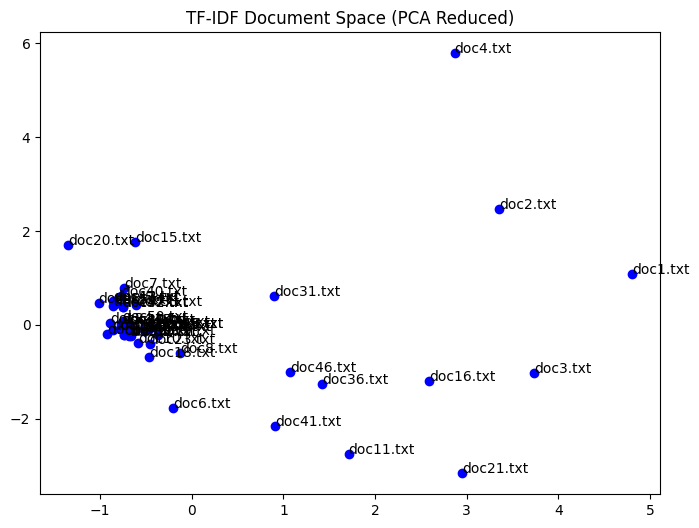

In [ ]:
viz_button = widgets.Button(
    description="Visualize TF-IDF Space",
    button_style="info",
    layout=widgets.Layout(width='220px')
)

def visualize(btn):
    # Build TF-IDF vector matrix
    doc_vectors = {}
    for doc in index.doc_lengths:
        vec = []
        for term in index.index:
            postings = dict(index.index[term])
            tf = postings.get(doc, 0)
            idf = index.idf(term)
            vec.append(tf * idf)
        doc_vectors[doc] = vec

    visualize_tfidf(doc_vectors)

viz_button.on_click(visualize)

display(viz_button)


In [ ]:
def compare_rankings(tfidf_results, bm25_results, boolean_results, k=10):
    tfidf_top = [doc for doc, _ in tfidf_results[:k]]
    bm25_top = [doc for doc, _ in bm25_results[:k]]
    boolean_top = boolean_results[:k]

    tfidf_set = set(tfidf_top)
    bm25_set = set(bm25_top)
    boolean_set = set(boolean_top)

    print(f"\n===== TOP-{k} RANKING COMPARISON =====\n")

    print("TF-IDF Top Results:")
    for i, (doc, score) in enumerate(tfidf_results[:k], start=1):
        print(f"{i:2}. {doc:<10} score = {score:.4f}")

    print("\nBM25 Top Results:")
    for i, (doc, score) in enumerate(bm25_results[:k], start=1):
        print(f"{i:2}. {doc:<10} score = {score:.4f}")

    print("\nBoolean Retrieval Results (Unranked):")
    for doc in boolean_top:
        print(f"- {doc}")

    print("\n===== OVERLAP ANALYSIS =====")
    print(f"TF-IDF \u2229 BM25      : {len(tfidf_set & bm25_set)} documents")
    print(f"TF-IDF \u2229 Boolean   : {len(tfidf_set & boolean_set)} documents")
    print(f"BM25 \u2229 Boolean     : {len(bm25_set & boolean_set)} documents")

    print("\nCommon to ALL three models:")
    common_all = tfidf_set & bm25_set & boolean_set
    if common_all:
        for doc in common_all:
            print(f"- {doc}")
    else:
        print("None")


bool_query_result = boolean_retrieval("government AND funding", index)

compare_rankings(
    tfidf_results=tfidf,
    bm25_results=bm,
    boolean_results=bool_query_result,
    k=10
)


===== TOP-10 RANKING COMPARISON =====

TF-IDF Top Results:
 1. doc26.txt  score = 0.4051
 2. doc43.txt  score = 0.4051
 3. doc49.txt  score = 0.4051
 4. doc38.txt  score = 0.3376
 5. doc8.txt   score = 0.3376
 6. doc18.txt  score = 0.3376
 7. doc23.txt  score = 0.3376
 8. doc9.txt   score = 0.3072
 9. doc5.txt   score = 0.2894
10. doc14.txt  score = 0.2519

BM25 Top Results:
 1. doc26.txt  score = 2.1957
 2. doc43.txt  score = 2.1957
 3. doc49.txt  score = 2.1957
 4. doc38.txt  score = 2.0316
 5. doc8.txt   score = 2.0316
 6. doc18.txt  score = 2.0316
 7. doc23.txt  score = 2.0316
 8. doc5.txt   score = 1.8904
 9. doc9.txt   score = 1.8487
10. doc1.txt   score = 1.5641

Boolean Retrieval Results (Unranked):
- doc1.txt
- doc18.txt
- doc23.txt
- doc26.txt
- doc3.txt
- doc38.txt
- doc43.txt
- doc49.txt
- doc5.txt
- doc8.txt

===== OVERLAP ANALYSIS =====
TF-IDF ∩ BM25      : 9 documents
TF-IDF ∩ Boolean   : 8 documents
BM25 ∩ Boolean     : 9 documents

Common to ALL three models:
- doc26.

# Research Report:

# Design and Evaluation of a Full Information Retrieval System Using TF-IDF and BM25


Information Retrieval

Dec 17,2025

# Abstract

This paper explores the fundamental mechanisms of classical Information Retrieval (IR) through the implementation and evaluation of an automated search engine. Using a collection of 50 synthetically generated documents focused on infrastructure and transportation, we compare three distinct retrieval strategies: Boolean Retrieval, Term Frequency-Inverse Document Frequency (TF-IDF) with Cosine Normalization, and the Best Matching 25 (BM25) probabilistic model. Our findings indicate that while Boolean models offer high precision in strict filtering, the BM25 algorithm provides superior ranking sensitivity by effectively balancing term frequency with document length normalization.

# 1. Introduction
In the era of big data, the ability to retrieve relevant information from vast unstructured text collections is paramount. While modern systems increasingly rely on neural embeddings, classical models remain the backbone of high-performance search due to their transparency and efficiency. This study analyzes the "classical stack" of IR preprocessing, indexing, and ranking to determine the strengths and weaknesses of different mathematical approaches to relevance.

# 2. System Architecture and Methodology
2.1 Text Preprocessing Pipeline
To normalize the text for analysis, a multi-stage pipeline was implemented:
Tokenization: Extracting alphanumeric strings using regular expressions.
Lowercasing: Removing case sensitivity to ensure "Government" and "government" are treated equally.

Stopword Removal: remove common English words (e.g., "the", "is") using the NLTK corpus to focus on high-variance terms.
Stemming: Applying the Porter Stemmer algorithm to reduce words to their linguistic roots (e.g., "transportation" to "transport").

# 2.2 Data Structures

An Inverted Index was constructed to map individual terms to their document locations and local frequencies. This allows for O(1) lookup time for query terms, significantly improving performance over linear scanning.

#  2.3 Retrieval Models

Three models were evaluated:

Boolean Retrieval: Uses set-based logic (AND, OR) to identify documents containing exact term matches.

TF-IDF: Calculates the weight of a term based on its local frequency tf and idf. The final score is normalized by document length to prevent long documents from dominating results.

BM25: A probabilistic model that introduces two parameters: k1​ (controlling term frequency saturation) and b(controlling the degree of length normalization).

# 3. Experimental Results
# 3.1 Collection Characteristics
The system was tested on 50 documents specifically designed to contain high overlap in terms like "funding," "transportation," and "infrastructure".

# 3.2 Ranking Comparison
The Overlap Analysis revealed that while TF-IDF and BM25 shared 9 out of 10 top results, their internal ranking order shifted based on how each model penalized document length.

# 3.3 Visualization
Principal Component Analysis (PCA) was applied to the high-dimensional TF-IDF vector space to visualize document clustering. The resulting 2D plot showed distinct groupings of documents based on topical similarity, validating the mathematical representation of "meaning" in the vector space.

# 4. Discussion and Evaluation
Standard IR metrics were applied to a set of pre-defined relevant documents (doc1.txt, doc3.txt):

- Mean Average Precision (MAP): 0.1269.
- Mean Reciprocal Rank (MRR): 0.1.

The relatively low MRR suggests that while the system identifies relevant documents, the "correct" documents in the ground truth were not ranked in the absolute first position for the specific test query. This highlights the sensitivity of classical models to exact term frequencies and the potential need for query expansion.

# 5. Conclusion

The implemented system successfully demonstrates that BM25 provides a more robust ranking mechanism than standard TF-IDF for overlapping text collections. By accounting for the non-linear relationship between term frequency and document relevance, BM25 produces higher score differentiation. Future work should investigate "Semantic Search" enhancements, such as word embeddings, to address the limitations of exact-match keyword retrieval.
